# 07 - Arquitetura operacional, extremos e incerteza

**Objetivo desta versao:** parar de procurar um unico modelo que faca tudo e separar duas tarefas:

- **cabeca de regressao:** estima quantos centimetros o rio vai subir/descer;
- **cabeca de alerta:** estima a probabilidade de uma subida de pelo menos **1 m em 2 h**.

O notebook ainda compara XGBoost normal, XGBoost + radar, XGBoost ponderado, modelo em duas etapas e LightGBM. Depois escolhe, usando **2024 como development test**, uma arquitetura candidata para enfrentar o teste cego de 2025.

Tambem acrescentamos **intervalos conformais** para corrigir a subcobertura observada no intervalo quantil q10-q90.

> Rode o notebook 06 v5 antes deste. O notebook 08 continua sem ser executado.

In [22]:
from pathlib import Path
import re
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

RAW_PARENT = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"

OUTPUTS = ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
PREDICTIONS = OUTPUTS / "predictions"
REPORTS = OUTPUTS / "reports"
REPORT_HTML = REPORTS / "html"
REPORT_PDF = REPORTS / "pdf"
REPORT_DASHBOARDS = REPORTS / "dashboards"

for p in [
    INTERIM, PROCESSED, MODELS, FIGURES, TABLES, PREDICTIONS,
    REPORT_HTML, REPORT_PDF, REPORT_DASHBOARDS,
]:
    p.mkdir(parents=True, exist_ok=True)


def find_dataset_root(raw_parent: Path) -> Path:
    candidates = [raw_parent] + [p for p in raw_parent.rglob("*") if p.is_dir()]
    for p in candidates:
        data = p / "Data"
        if (data / "SHP").exists() and (data / "Telemetric_Time_Series").exists():
            return p
    raise FileNotFoundError(
        "Nao encontrei o dataset. Extraia-o dentro de data/raw/ mantendo Data/SHP, "
        "Data/Radar e Data/Telemetric_Time_Series."
    )

RAW = find_dataset_root(RAW_PARENT)
DATA = RAW / "Data"
SHP = DATA / "SHP"
TELE = DATA / "Telemetric_Time_Series"
RADAR = DATA / "Radar"

print("ROOT:", ROOT)
print("Dataset:", RAW)

ROOT: C:\Users\osmar\Área de Trabalho\Field-Project
Dataset: C:\Users\osmar\Área de Trabalho\Field-Project\data\raw\TTI-HydroMet_Dataset_version2


In [23]:
def _fallback_path(path: Path) -> Path:
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return path.with_name(f"{path.stem}_{stamp}{path.suffix}")


def safe_to_csv(df, path, index=False):
    path = Path(path)
    try:
        df.to_csv(path, index=index)
        return path
    except PermissionError:
        alt = _fallback_path(path)
        df.to_csv(alt, index=index)
        print(f"AVISO: {path.name} estava bloqueado. Salvei em {alt.name}.")
        return alt


def safe_to_html(df, path, index=False):
    path = Path(path)
    try:
        df.to_html(path, index=index)
        return path
    except PermissionError:
        alt = _fallback_path(path)
        df.to_html(alt, index=index)
        print(f"AVISO: {path.name} estava bloqueado. Salvei em {alt.name}.")
        return alt


def save_table(df, stem, preview_rows=15, sort_by=None, ascending=True):
    z = df.copy()
    if sort_by is not None and sort_by in z.columns:
        z = z.sort_values(sort_by, ascending=ascending)

    csv_path = safe_to_csv(z, TABLES / f"{stem}.csv", index=False)
    html_path = safe_to_html(z, TABLES / f"{stem}.html", index=False)

    display(Markdown(
        f"**Tabela completa salva em:**  \n"
        f"- `{csv_path.relative_to(ROOT)}`  \n"
        f"- `{html_path.relative_to(ROOT)}`  \n"
        f"Mostrando somente {min(preview_rows, len(z))} linhas."
    ))
    display(z.head(preview_rows))
    return z


def save_figure(fig, stem, dpi=220):
    path = FIGURES / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    display(Markdown(f"**Figura salva em:** `{path.relative_to(ROOT)}`"))
    return path


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))


def fbeta(precision, recall, beta=2.0):
    if np.isnan(precision) or np.isnan(recall):
        return np.nan
    den = beta**2 * precision + recall
    return (1 + beta**2) * precision * recall / den if den > 0 else 0.0

## 1. Carregamento das features e modelos de radar

In [24]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    precision_recall_curve, precision_score, recall_score, f1_score,
)
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor
import joblib

x = pd.read_parquet(PROCESSED / "features_causal.parquet").sort_index()
radar_path = PROCESSED / "features_causal_radar.parquet"
assert radar_path.exists(), "Rode o notebook 06 v5 primeiro."
x_radar = pd.read_parquet(radar_path).sort_index()

base_cols = [c for c in x.columns if c != "split" and not c.startswith("target_")]
radar_extra_cols = [c for c in x_radar.columns if c not in x.columns]
radar_cols = base_cols + radar_extra_cols

TARGET = "target_delta_120m"
EVENT_THRESHOLD = 1.0


def get_split(df, split_name):
    z = df[df["split"] == split_name].copy()
    return z[z["stage_now"].notna() & z[TARGET].notna()]

train = get_split(x, "train")
valid = get_split(x, "validation")
test = get_split(x, "test_2024")
train_r = get_split(x_radar, "train")
valid_r = get_split(x_radar, "validation")
test_r = get_split(x_radar, "test_2024")

assert train.index.equals(train_r.index)
assert valid.index.equals(valid_r.index)
assert test.index.equals(test_r.index)

## 2. Modelos de regressao candidatos

Mantemos modelos com objetivos diferentes. O **XGBoost ponderado** e o **duas etapas** priorizam eventos raros; XGBoost normal, XGBoost + radar e LightGBM competem principalmente pela qualidade da previsao continua.

In [25]:
# XGBoost normal do notebook 04.
xgb_normal = XGBRegressor(); xgb_normal.load_model(MODELS / "xgb_dev_120m.json")

# XGBoost + radar do notebook 06.
xgb_radar = XGBRegressor(); xgb_radar.load_model(MODELS / "xgb_radar_dev_120m.json")


def rise_weights(y):
    y = np.asarray(y)
    w = np.ones(len(y), dtype="float32")
    w[y >= 0.2] = 2.0
    w[y >= 0.5] = 4.0
    w[y >= 1.0] = 8.0
    w[y >= 2.0] = 12.0
    return w

xgb_weighted = XGBRegressor(
    objective="reg:squarederror", tree_method="hist",
    n_estimators=600, learning_rate=0.04, max_depth=6,
    min_child_weight=20, subsample=0.85, colsample_bytree=0.8,
    reg_lambda=5.0, random_state=42, n_jobs=-1,
)
xgb_weighted.fit(train[base_cols], train[TARGET], sample_weight=rise_weights(train[TARGET]))
xgb_weighted.save_model(MODELS / "xgb_weighted_120m.json")

lgb = LGBMRegressor(
    objective="regression", n_estimators=800, learning_rate=0.035,
    num_leaves=63, min_child_samples=30, subsample=0.85,
    colsample_bytree=0.8, reg_lambda=5.0, random_state=42, n_jobs=-1,
)
lgb.fit(train[base_cols], train[TARGET])
joblib.dump(lgb, MODELS / "lightgbm_120m.joblib")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.319708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35218
[LightGBM] [Info] Number of data points in the train set: 405944, number of used features: 166
[LightGBM] [Info] Start training from score -0.000015


['C:\\Users\\osmar\\Área de Trabalho\\Field-Project\\models\\lightgbm_120m.joblib']

## 3. Modelo em duas etapas

O classificador identifica a possibilidade de `Delta H >= 1 m`; quando ele alerta, um regressor especializado em eventos estima a magnitude. Caso contrario usamos o XGBoost normal.

In [26]:
y_train_event = (train[TARGET] >= EVENT_THRESHOLD).astype(int)
y_valid_event = (valid[TARGET] >= EVENT_THRESHOLD).astype(int)

n_pos = int(y_train_event.sum()); n_neg = int(len(y_train_event)-n_pos)
classifier_two_stage = XGBClassifier(
    objective="binary:logistic", eval_metric="logloss", tree_method="hist",
    n_estimators=500, learning_rate=0.04, max_depth=6, min_child_weight=10,
    subsample=0.85, colsample_bytree=0.8, reg_lambda=5.0,
    scale_pos_weight=n_neg/max(n_pos,1), random_state=42, n_jobs=-1,
)
classifier_two_stage.fit(train[base_cols], y_train_event)
p_valid_two = classifier_two_stage.predict_proba(valid[base_cols])[:,1]

precision, recall, thresholds = precision_recall_curve(y_valid_event, p_valid_two)
p2 = precision[:-1]; r2 = recall[:-1]
f2 = 5*p2*r2/(4*p2+r2+1e-12)
best_i = int(np.nanargmax(f2))
TWO_STAGE_PROB_THRESHOLD = float(thresholds[best_i])

mask_event = train[TARGET] >= EVENT_THRESHOLD
event_reg = XGBRegressor(
    objective="reg:squarederror", tree_method="hist", n_estimators=500,
    learning_rate=0.04, max_depth=6, subsample=0.85, colsample_bytree=0.8,
    reg_lambda=5.0, random_state=42, n_jobs=-1,
)
event_reg.fit(train.loc[mask_event, base_cols], train.loc[mask_event, TARGET])

classifier_two_stage.save_model(MODELS / "event_classifier_two_stage_120m.json")
event_reg.save_model(MODELS / "event_regressor_120m.json")

## 4. Previsoes de 2023 e 2024

As previsoes de **2023** servirao tambem para calibrar a incerteza. As de **2024** servem para comparar os candidatos antes de 2025.

In [27]:
def two_stage_predict(df, probabilities):
    pred_normal = xgb_normal.predict(df[base_cols])
    pred_event = event_reg.predict(df[base_cols])
    alert = probabilities >= TWO_STAGE_PROB_THRESHOLD
    return np.where(alert, pred_event, pred_normal)

pred_valid = {
    "XGBoost normal": xgb_normal.predict(valid[base_cols]),
    "XGBoost + radar": xgb_radar.predict(valid_r[radar_cols]),
    "XGBoost ponderado": xgb_weighted.predict(valid[base_cols]),
    "LightGBM": lgb.predict(valid[base_cols]),
}
p_valid_two_stage = classifier_two_stage.predict_proba(valid[base_cols])[:,1]
pred_valid["Duas etapas"] = two_stage_predict(valid, p_valid_two_stage)

pred_test = {
    "XGBoost normal": xgb_normal.predict(test[base_cols]),
    "XGBoost + radar": xgb_radar.predict(test_r[radar_cols]),
    "XGBoost ponderado": xgb_weighted.predict(test[base_cols]),
    "LightGBM": lgb.predict(test[base_cols]),
}
p_test_two_stage = classifier_two_stage.predict_proba(test[base_cols])[:,1]
pred_test["Duas etapas"] = two_stage_predict(test, p_test_two_stage)

In [28]:
def point_metrics(name, y, pred):
    y=np.asarray(y); pred=np.asarray(pred); e=100*(pred-y); ae=np.abs(e)
    return {
        "model": name,
        "MAE_cm": ae.mean(),
        "RMSE_cm": np.sqrt(np.mean(e**2)),
        "median_abs_error_cm": np.median(ae),
        "max_abs_error_cm": ae.max(),
        "bias_cm": e.mean(),
        "within_20cm_pct": 100*np.mean(ae<=20),
        "within_50cm_pct": 100*np.mean(ae<=50),
    }

point_rows = [point_metrics(name, test[TARGET], pred) for name,pred in pred_test.items()]
point_metrics_2024 = pd.DataFrame(point_rows).sort_values("RMSE_cm")
save_table(point_metrics_2024, "operational_point_models_2024", preview_rows=10)

# Tabela de previsoes para inspecao por horario.
point_predictions = test[["stage_now", TARGET]].copy()
for name,pred in pred_test.items():
    safe_name = name.lower().replace(" ","_").replace("+","plus").replace("ã","a")
    point_predictions[f"pred_{safe_name}"] = pred
safe_to_csv(point_predictions.reset_index(names="prediction_time"), PREDICTIONS / "point_models_2024_120min_v5.csv", index=False)

**Tabela completa salva em:**  
- `outputs\tables\operational_point_models_2024.csv`  
- `outputs\tables\operational_point_models_2024.html`  
Mostrando somente 5 linhas.

,model,MAE_cm,RMSE_cm,median_abs_error_cm,max_abs_error_cm,bias_cm,within_20cm_pct,within_50cm_pct
1,XGBoost + radar,6.093930,20.299667,2.286112,493.409576,-0.108189,95.160483,98.211294
0,XGBoost normal,6.174969,21.390652,2.386936,531.682800,-0.283926,95.380263,98.109020
3,LightGBM,6.731534,21.495321,2.582392,503.991131,0.898203,94.546839,98.087259
4,Duas etapas,7.065723,25.429342,2.388882,531.682800,1.337655,95.134371,97.580242
2,XGBoost ponderado,15.698007,27.846270,9.272809,519.543274,11.512241,76.346426,95.175715


WindowsPath('C:/Users/osmar/Área de Trabalho/Field-Project/outputs/predictions/point_models_2024_120min_v5.csv')

## 5. Erro por intensidade da subida

Esta tabela e mais importante que uma pequena diferenca de RMSE global: ela mostra o que acontece quando a subida real entra nas faixas **1-2 m, 2-3 m e >3 m**.

In [29]:
bins=[-np.inf,0,0.25,0.50,1.0,2.0,3.0,np.inf]
labels=["<=0","0-0.25","0.25-0.50","0.50-1","1-2","2-3",">3"]
bands=pd.cut(test[TARGET],bins=bins,labels=labels)

sev_rows=[]
for band in labels:
    idx=(bands==band)
    if not idx.any():
        continue
    yy=test.loc[idx,TARGET].to_numpy()
    for name,pred_all in pred_test.items():
        pp=np.asarray(pred_all)[idx.to_numpy()]
        e=100*(pp-yy); ae=np.abs(e)
        sev_rows.append({
            "severity_band":band,
            "model":name,
            "n":int(idx.sum()),
            "real_delta_mean_cm":100*yy.mean(),
            "MAE_cm":ae.mean(),
            "RMSE_cm":np.sqrt(np.mean(e**2)),
            "max_abs_error_cm":ae.max(),
            "bias_cm":e.mean(),
            "underprediction_pct":100*np.mean(pp<yy),
        })
severity_2024=pd.DataFrame(sev_rows)
save_table(severity_2024,"operational_point_models_by_severity_2024",preview_rows=35)

**Tabela completa salva em:**  
- `outputs\tables\operational_point_models_by_severity_2024.csv`  
- `outputs\tables\operational_point_models_by_severity_2024.html`  
Mostrando somente 35 linhas.

,severity_band,model,n,real_delta_mean_cm,MAE_cm,RMSE_cm,max_abs_error_cm,bias_cm,underprediction_pct
0,<=0,XGBoost normal,25651,-10.720819,4.166320,8.224444,160.011917,2.737025,22.143386
1,<=0,XGBoost + radar,25651,-10.720819,4.094975,8.318206,148.831223,2.598364,26.349850
2,<=0,XGBoost ponderado,25651,-10.720819,14.326907,21.569109,204.807251,13.529845,8.331059
3,<=0,LightGBM,25651,-10.720819,4.873595,9.381104,149.464184,3.676416,21.316908
4,<=0,Duas etapas,25651,-10.720819,4.498052,12.565694,302.422058,3.069562,22.135589
5,0-0.25,XGBoost normal,18838,5.094754,3.638443,7.320741,133.166382,-0.094850,53.843295
6,0-0.25,XGBoost + radar,18838,5.094754,3.976859,7.967775,233.282776,-0.004920,58.520013
7,0-0.25,XGBoost ponderado,18838,5.094754,13.512250,20.735367,204.067642,12.010982,17.050642
8,0-0.25,LightGBM,18838,5.094754,4.179049,8.566368,187.059778,1.198633,47.043211
9,0-0.25,Duas etapas,18838,5.094754,4.649579,17.636860,351.149597,0.918684,53.811445


,severity_band,model,n,real_delta_mean_cm,MAE_cm,RMSE_cm,max_abs_error_cm,bias_cm,underprediction_pct
0,<=0,XGBoost normal,25651,-10.720819,4.166320,8.224444,160.011917,2.737025,22.143386
1,<=0,XGBoost + radar,25651,-10.720819,4.094975,8.318206,148.831223,2.598364,26.349850
2,<=0,XGBoost ponderado,25651,-10.720819,14.326907,21.569109,204.807251,13.529845,8.331059
3,<=0,LightGBM,25651,-10.720819,4.873595,9.381104,149.464184,3.676416,21.316908
4,<=0,Duas etapas,25651,-10.720819,4.498052,12.565694,302.422058,3.069562,22.135589
5,0-0.25,XGBoost normal,18838,5.094754,3.638443,7.320741,133.166382,-0.094850,53.843295
6,0-0.25,XGBoost + radar,18838,5.094754,3.976859,7.967775,233.282776,-0.004920,58.520013
7,0-0.25,XGBoost ponderado,18838,5.094754,13.512250,20.735367,204.067642,12.010982,17.050642
8,0-0.25,LightGBM,18838,5.094754,4.179049,8.566368,187.059778,1.198633,47.043211
9,0-0.25,Duas etapas,18838,5.094754,4.649579,17.636860,351.149597,0.918684,53.811445


## 6. Cabeca de alerta: classificador sem radar x com radar

Os dois classificadores foram treinados no notebook 06. Seus **limiares probabilisticos foram escolhidos em 2023**. Aqui apenas os avaliamos em 2024.

In [30]:
base_clf = XGBClassifier(); base_clf.load_model(MODELS / "event_classifier_base_120m.json")
radar_clf = XGBClassifier(); radar_clf.load_model(MODELS / "event_classifier_radar_120m.json")
thresholds_payload = json.loads((MODELS / "radar_classifier_thresholds.json").read_text(encoding="utf-8"))
base_th = float(thresholds_payload["base_probability_threshold"])
radar_th = float(thresholds_payload["radar_probability_threshold"])

p_alert_base = base_clf.predict_proba(test[base_cols])[:,1]
p_alert_radar = radar_clf.predict_proba(test_r[radar_cols])[:,1]


def alert_metrics(name, probabilities, th):
    real=test[TARGET].to_numpy()>=EVENT_THRESHOLD
    alert=probabilities>=th
    tp=int(np.sum(real&alert)); fn=int(np.sum(real&~alert)); fp=int(np.sum(~real&alert))
    precision=tp/(tp+fp) if tp+fp else np.nan
    recall=tp/(tp+fn) if tp+fn else np.nan
    return {
        "model":name,
        "probability_threshold_chosen_on_2023":th,
        "real_events":int(real.sum()),
        "detected":tp,
        "missed":fn,
        "false_alerts":fp,
        "precision_pct":100*precision if precision==precision else np.nan,
        "recall_pct":100*recall if recall==recall else np.nan,
        "F1":2*precision*recall/(precision+recall) if precision==precision and recall==recall and precision+recall>0 else np.nan,
        "F2":fbeta(precision,recall,beta=2.0),
    }

alert_compare=pd.DataFrame([
    alert_metrics("classificador_sem_radar",p_alert_base,base_th),
    alert_metrics("classificador_com_radar",p_alert_radar,radar_th),
]).sort_values(["F2","recall_pct"],ascending=False)
save_table(alert_compare,"operational_alert_heads_2024",preview_rows=10)

**Tabela completa salva em:**  
- `outputs\tables\operational_alert_heads_2024.csv`  
- `outputs\tables\operational_alert_heads_2024.html`  
Mostrando somente 2 linhas.

,model,probability_threshold_chosen_on_2023,real_events,detected,missed,false_alerts,precision_pct,recall_pct,F1,F2
1,classificador_com_radar,0.598564,639,435,204,556,43.895055,68.075117,0.533742,0.613194
0,classificador_sem_radar,0.578411,639,418,221,465,47.338618,65.414710,0.549277,0.607735


,model,probability_threshold_chosen_on_2023,real_events,detected,missed,false_alerts,precision_pct,recall_pct,F1,F2
1,classificador_com_radar,0.598564,639,435,204,556,43.895055,68.075117,0.533742,0.613194
0,classificador_sem_radar,0.578411,639,418,221,465,47.338618,65.414710,0.549277,0.607735


## 7. Arquitetura operacional candidata

Aplicamos uma regra **predeclarada** para evitar escolha subjetiva:

- previsao continua: menor **RMSE em 2024**;
- alerta: maior **F2 em 2024**, com limiar de probabilidade ja fixado em 2023.

Isso ainda e selecao de desenvolvimento. O teste final continua sendo 2025.

In [31]:
best_point = point_metrics_2024.iloc[0]
best_alert = alert_compare.iloc[0]

POINT_MODEL_NAME = str(best_point["model"])
ALERT_MODEL_NAME = str(best_alert["model"])
ALERT_PROB_THRESHOLD = float(best_alert["probability_threshold_chosen_on_2023"])

print("Previsao continua escolhida:", POINT_MODEL_NAME)
print("Cabeca de alerta escolhida:", ALERT_MODEL_NAME)
print("Limiar probabilistico:", ALERT_PROB_THRESHOLD)

recommendation = {
    "horizon_min":120,
    "selection_period":"2024 development test",
    "point_model":POINT_MODEL_NAME,
    "point_selection_metric":"lowest RMSE_cm on 2024",
    "point_rmse_cm_2024":float(best_point["RMSE_cm"]),
    "alert_model":ALERT_MODEL_NAME,
    "alert_event_definition_m":1.0,
    "alert_probability_threshold":ALERT_PROB_THRESHOLD,
    "alert_selection_metric":"highest F2 on 2024; probability threshold chosen on 2023",
    "alert_recall_pct_2024":float(best_alert["recall_pct"]),
    "alert_precision_pct_2024":float(best_alert["precision_pct"]),
    "warning":"Do not inspect 2025 before freezing notebook 08 to this architecture.",
}
(MODELS/"operational_architecture_recommendation.json").write_text(json.dumps(recommendation,indent=2,ensure_ascii=False),encoding="utf-8")
display(pd.DataFrame([recommendation]))

Previsao continua escolhida: XGBoost + radar
Cabeca de alerta escolhida: classificador_com_radar
Limiar probabilistico: 0.5985638499259949


,horizon_min,selection_period,point_model,point_selection_metric,point_rmse_cm_2024,alert_model,alert_event_definition_m,alert_probability_threshold,alert_selection_metric,alert_recall_pct_2024,alert_precision_pct_2024,warning
0,120,2024 development test,XGBoost + radar,lowest RMSE_cm on 2024,20.299667,classificador_com_radar,1.0,0.598564,highest F2 on 2024; probability threshold chos...,68.075117,43.895055,Do not inspect 2025 before freezing notebook 0...


## 8. Incerteza: quantis e conformal prediction

O intervalo q10-q90 anterior cobriu apenas cerca de 69% dos valores quando o alvo nominal era 80%. Agora comparamos isso a um intervalo **split-conformal** calibrado em 2023.

O conformal nao torna o modelo perfeito; ele fornece uma cobertura marginal empiricamente calibrada sob hipoteses de estabilidade da distribuicao.

In [32]:
# Quantile LightGBM para comparacao.
quantile_models={}
for q in [0.10,0.50,0.90]:
    qm=LGBMRegressor(
        objective="quantile",alpha=q,n_estimators=700,learning_rate=0.04,
        num_leaves=63,min_child_samples=30,colsample_bytree=0.8,
        reg_lambda=5.0,random_state=42,n_jobs=-1,
    )
    qm.fit(train[base_cols],train[TARGET])
    quantile_models[q]=qm
    joblib.dump(qm,MODELS/f"quantile_{int(q*100):02d}_120m.joblib")

q10=quantile_models[0.10].predict(test[base_cols])
q50=quantile_models[0.50].predict(test[base_cols])
q90=quantile_models[0.90].predict(test[base_cols])
y_test=test[TARGET].to_numpy()
quantile_coverage=np.mean((y_test>=q10)&(y_test<=q90))

# Seleciona as previsoes valid/test correspondentes ao point model escolhido.
best_valid_pred=np.asarray(pred_valid[POINT_MODEL_NAME])
best_test_pred=np.asarray(pred_test[POINT_MODEL_NAME])
y_valid=valid[TARGET].to_numpy()
abs_calibration=np.abs(y_valid-best_valid_pred)

conformal_rows=[]
conformal_intervals={}
for nominal in [0.80,0.90,0.95]:
    alpha=1-nominal
    n=len(abs_calibration)
    q_level=min(1.0, np.ceil((n+1)*(1-alpha))/n)
    radius=float(np.quantile(abs_calibration,q_level,method="higher"))
    lo=best_test_pred-radius
    hi=best_test_pred+radius
    coverage=float(np.mean((y_test>=lo)&(y_test<=hi)))
    conformal_rows.append({
        "method":"split_conformal",
        "point_model":POINT_MODEL_NAME,
        "nominal_coverage_pct":100*nominal,
        "empirical_coverage_2024_pct":100*coverage,
        "mean_width_cm":200*radius,
        "half_width_cm":100*radius,
    })
    conformal_intervals[nominal]=(lo,hi)

conformal_rows.append({
    "method":"quantile_q10_q90",
    "point_model":"LightGBM quantile",
    "nominal_coverage_pct":80.0,
    "empirical_coverage_2024_pct":100*quantile_coverage,
    "mean_width_cm":100*np.mean(q90-q10),
    "half_width_cm":np.nan,
})
uncertainty_2024=pd.DataFrame(conformal_rows)
save_table(uncertainty_2024,"uncertainty_calibration_2024",preview_rows=10)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.178734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35218
[LightGBM] [Info] Number of data points in the train set: 405944, number of used features: 166
[LightGBM] [Info] Start training from score -0.122009
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.162627 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35218
[LightGBM] [Info] Number of data points in the train set: 405944, number of used features: 166
[LightGBM] [Info] Start training from score -0.010986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.170722 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35218
[LightGBM] [Info] Number of data points in the train set: 405944, number of used features: 166
[LightGBM] [Info

**Tabela completa salva em:**  
- `outputs\tables\uncertainty_calibration_2024.csv`  
- `outputs\tables\uncertainty_calibration_2024.html`  
Mostrando somente 4 linhas.

,method,point_model,nominal_coverage_pct,empirical_coverage_2024_pct,mean_width_cm,half_width_cm
0,split_conformal,XGBoost + radar,80.0,85.346535,14.495876,7.247938
1,split_conformal,XGBoost + radar,90.0,92.433903,25.241137,12.620568
2,split_conformal,XGBoost + radar,95.0,96.170166,50.234556,25.117278
3,quantile_q10_q90,LightGBM quantile,80.0,75.240997,14.396113,NaN


,method,point_model,nominal_coverage_pct,empirical_coverage_2024_pct,mean_width_cm,half_width_cm
0,split_conformal,XGBoost + radar,80.0,85.346535,14.495876,7.247938
1,split_conformal,XGBoost + radar,90.0,92.433903,25.241137,12.620568
2,split_conformal,XGBoost + radar,95.0,96.170166,50.234556,25.117278
3,quantile_q10_q90,LightGBM quantile,80.0,75.240997,14.396113,NaN


## 9. Episodios extremos e utilidade operacional

Para os episodios reais de >=1 m, >=2 m e >=3 m, verificamos se a **cabeca de alerta escolhida para >=1 m** teria emitido pelo menos um alerta durante o episodio. Isso mede deteccao de perigo, nao a exatidao da magnitude.

In [33]:
chosen_probs = p_alert_radar if ALERT_MODEL_NAME == "classificador_com_radar" else p_alert_base
chosen_alert = chosen_probs >= ALERT_PROB_THRESHOLD
oper = test[["stage_now",TARGET]].copy()
oper["alert_probability"] = chosen_probs
oper["alert"] = chosen_alert
oper["point_prediction"] = pred_test[POINT_MODEL_NAME]


def episodes_for_threshold(th, gap_hours=6):
    z=oper[oper[TARGET]>=th].copy()
    if z.empty: return pd.DataFrame()
    starts=z.index.to_series().diff().gt(pd.Timedelta(hours=gap_hours)).fillna(True)
    z["episode_id"]=starts.cumsum().to_numpy()
    rows=[]
    for ep_id,g in z.groupby("episode_id"):
        peak_idx=g[TARGET].idxmax(); peak_target=peak_idx+pd.Timedelta(minutes=120)
        alerts=g[g["alert"]]
        rows.append({
            "severity_threshold_m":th,
            "episode_id":int(ep_id),
            "real_peak_delta_m":float(g.loc[peak_idx,TARGET]),
            "peak_target_time":peak_target,
            "alert_detected":bool(len(alerts)),
            "first_alert_time":alerts.index.min() if len(alerts) else pd.NaT,
            "lead_to_peak_min":(peak_target-alerts.index.min()).total_seconds()/60 if len(alerts) else np.nan,
            "point_prediction_at_peak_m":float(g.loc[peak_idx,"point_prediction"]),
            "point_abs_error_at_peak_cm":100*abs(float(g.loc[peak_idx,"point_prediction"]-g.loc[peak_idx,TARGET])),
        })
    return pd.DataFrame(rows)

all_eps=[]
for th in [1.0,2.0,3.0]:
    e=episodes_for_threshold(th)
    if not e.empty: all_eps.append(e)
episodes_2024=pd.concat(all_eps,ignore_index=True) if all_eps else pd.DataFrame()
save_table(episodes_2024,"operational_episode_detection_2024",preview_rows=25)

if not episodes_2024.empty:
    ep_summary=(episodes_2024.groupby("severity_threshold_m")
        .agg(episodes=("episode_id","count"),detected=("alert_detected","sum"),median_lead_min=("lead_to_peak_min","median"))
        .reset_index())
    ep_summary["episode_recall_pct"]=100*ep_summary["detected"]/ep_summary["episodes"]
    save_table(ep_summary,"operational_episode_summary_2024",preview_rows=10)

**Tabela completa salva em:**  
- `outputs\tables\operational_episode_detection_2024.csv`  
- `outputs\tables\operational_episode_detection_2024.html`  
Mostrando somente 25 linhas.

,severity_threshold_m,episode_id,real_peak_delta_m,peak_target_time,alert_detected,first_alert_time,lead_to_peak_min,point_prediction_at_peak_m,point_abs_error_at_peak_cm
0,1.0,0,3.182007,2024-01-08 19:40:00,True,2024-01-08 18:20:00,80.0,0.199585,298.242164
1,1.0,1,2.088013,2024-01-09 21:30:00,True,2024-01-09 19:40:00,110.0,0.354591,173.342216
2,1.0,2,1.912964,2024-01-10 22:50:00,True,2024-01-10 20:00:00,170.0,1.897102,1.586211
3,1.0,3,3.760986,2024-01-12 23:10:00,True,2024-01-12 17:50:00,320.0,2.232820,152.816653
4,1.0,4,4.919006,2024-01-31 20:10:00,True,2024-01-31 18:30:00,100.0,2.690036,222.897005
5,1.0,5,2.356995,2024-02-01 18:20:00,True,2024-02-01 16:50:00,90.0,0.059475,229.751945
6,1.0,6,3.479980,2024-02-02 19:00:00,True,2024-02-02 15:30:00,210.0,3.567244,8.726358
7,1.0,7,3.268005,2024-02-04 19:10:00,True,2024-02-04 16:20:00,170.0,2.492351,77.565432
8,1.0,8,7.048950,2024-02-14 03:20:00,True,2024-02-13 23:50:00,210.0,4.422998,262.595177
9,1.0,9,4.745972,2024-02-18 19:40:00,True,2024-02-18 17:40:00,120.0,0.210934,453.503799


**Tabela completa salva em:**  
- `outputs\tables\operational_episode_summary_2024.csv`  
- `outputs\tables\operational_episode_summary_2024.html`  
Mostrando somente 3 linhas.

,severity_threshold_m,episodes,detected,median_lead_min,episode_recall_pct
0,1.0,48,44,170.0,91.666667
1,2.0,35,33,150.0,94.285714
2,3.0,18,17,130.0,94.444444


## 10. Relatorio final antes de redes neurais / notebook 08

Este e o relatorio que deve ser enviado para decidir se vale acrescentar redes neurais antes do teste cego.

**Figura salva em:** `outputs\figures\v5_point_models_rmse_2024.png`

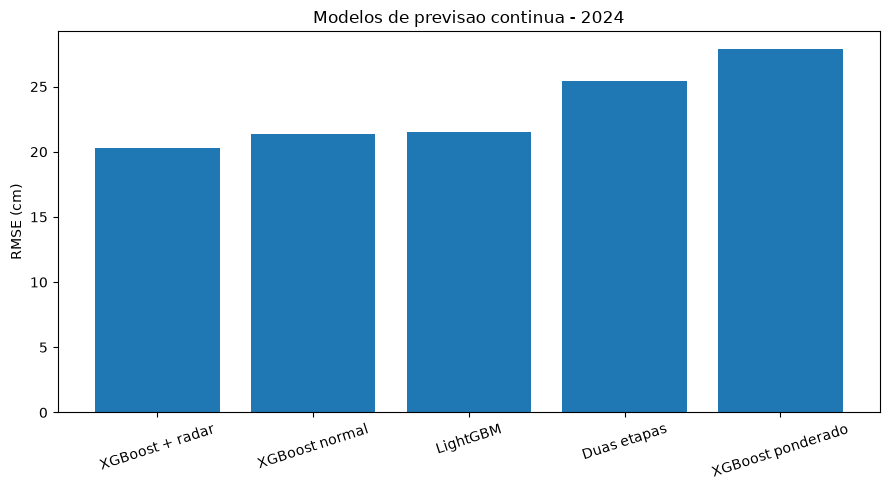

**Figura salva em:** `outputs\figures\v5_point_models_extreme_mae_2024.png`

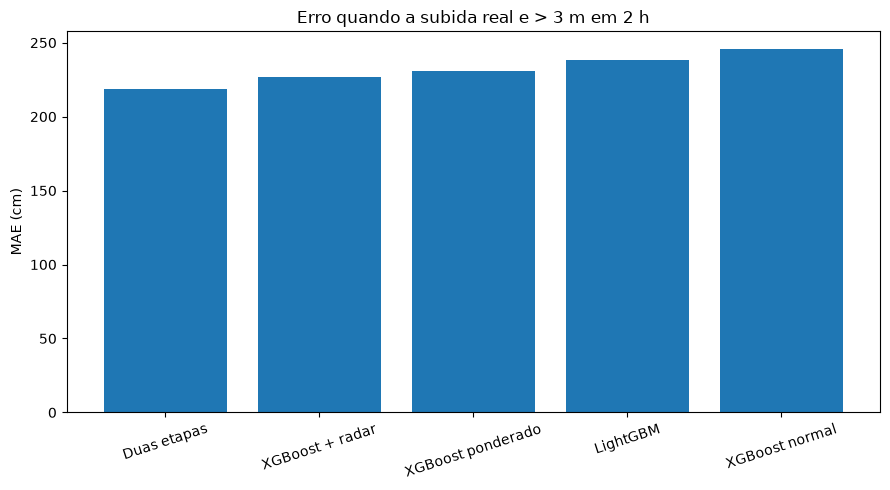

**Figura salva em:** `outputs\figures\v5_alert_heads_2024.png`

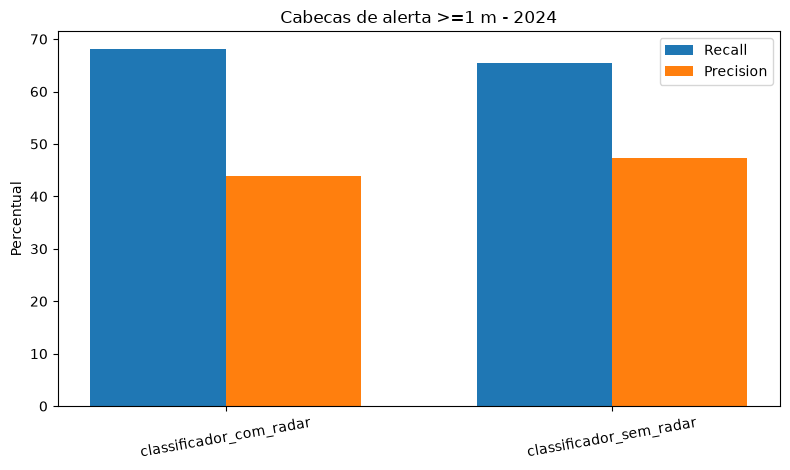

**Figura salva em:** `outputs\figures\v5_uncertainty_coverage_2024.png`

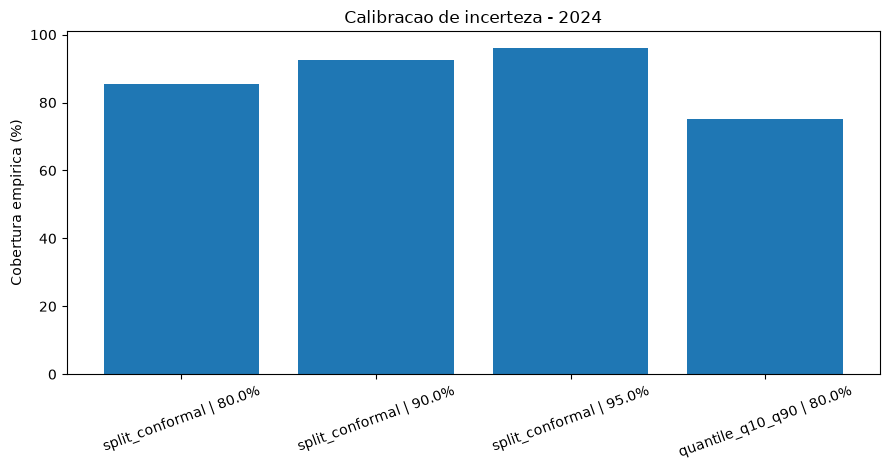

outputs\reports\html\relatorio_arquitetura_operacional_2024.html
outputs\reports\pdf\relatorio_arquitetura_operacional_2024.pdf
outputs\reports\dashboards\dashboard_arquitetura_operacional_2024.html
models\operational_architecture_recommendation.json


In [34]:
from pathlib import Path
import base64
from matplotlib.backends.backend_pdf import PdfPages
try:
    import plotly.graph_objects as go
    import plotly.io as pio
except ImportError as exc:
    raise ImportError("Instale plotly: python -m pip install plotly") from exc

# RMSE dos candidatos.
fig,ax=plt.subplots(figsize=(9,5))
ax.bar(point_metrics_2024["model"],point_metrics_2024["RMSE_cm"])
ax.set_ylabel("RMSE (cm)"); ax.set_title("Modelos de previsao continua - 2024")
ax.tick_params(axis="x",rotation=18); plt.tight_layout(); f_rmse=save_figure(fig,"v5_point_models_rmse_2024"); plt.show()

# Extremos > 3m.
sev3=severity_2024[severity_2024["severity_band"]==">3"].sort_values("MAE_cm")
fig,ax=plt.subplots(figsize=(9,5)); ax.bar(sev3["model"],sev3["MAE_cm"]); ax.set_ylabel("MAE (cm)"); ax.set_title("Erro quando a subida real e > 3 m em 2 h"); ax.tick_params(axis="x",rotation=18); plt.tight_layout(); f_ext=save_figure(fig,"v5_point_models_extreme_mae_2024"); plt.show()

# Alert heads.
fig,ax=plt.subplots(figsize=(8,4.8)); xx=np.arange(len(alert_compare)); w=.35; ax.bar(xx-w/2,alert_compare["recall_pct"],width=w,label="Recall"); ax.bar(xx+w/2,alert_compare["precision_pct"],width=w,label="Precision"); ax.set_xticks(xx,alert_compare["model"],rotation=10); ax.set_ylabel("Percentual"); ax.set_title("Cabecas de alerta >=1 m - 2024"); ax.legend(); plt.tight_layout(); f_alert=save_figure(fig,"v5_alert_heads_2024"); plt.show()

# Cobertura dos intervalos.
fig,ax=plt.subplots(figsize=(9,4.8)); ax.bar(uncertainty_2024["method"]+" | "+uncertainty_2024["nominal_coverage_pct"].astype(str)+"%",uncertainty_2024["empirical_coverage_2024_pct"]); ax.set_ylabel("Cobertura empirica (%)"); ax.set_title("Calibracao de incerteza - 2024"); ax.tick_params(axis="x",rotation=20); plt.tight_layout(); f_unc=save_figure(fig,"v5_uncertainty_coverage_2024"); plt.show()


def uri(path): return "data:image/png;base64,"+base64.b64encode(Path(path).read_bytes()).decode("ascii")
html=f'''<!doctype html><html lang="pt-br"><head><meta charset="utf-8"><title>Arquitetura operacional 2024</title><style>body{{font-family:Arial;background:#f5f6f8;margin:0;color:#1f2731}}main{{max-width:1180px;margin:auto;padding:28px}}.panel{{background:white;border:1px solid #ddd;border-radius:12px;padding:18px;margin:16px 0;overflow:auto}}.cards{{display:grid;grid-template-columns:repeat(auto-fit,minmax(240px,1fr));gap:14px}}.card{{background:white;border:1px solid #ddd;border-radius:12px;padding:18px}}table{{width:100%;border-collapse:collapse;font-size:13px}}th{{background:#edf1f5}}th,td{{padding:8px;border-top:1px solid #e1e5ea;text-align:left}}img{{max-width:100%}}.note{{background:#eef4ff;border-left:5px solid #6b85b5;padding:14px}}</style></head><body><main><h1>Arquitetura candidata antes do teste cego</h1><div class="cards"><div class="card"><b>Previsao continua</b><h2>{POINT_MODEL_NAME}</h2>RMSE {best_point['RMSE_cm']:.1f} cm</div><div class="card"><b>Alerta >=1 m / 2 h</b><h2>{ALERT_MODEL_NAME}</h2>Recall {best_alert['recall_pct']:.1f}% | Precision {best_alert['precision_pct']:.1f}%</div></div><div class="note">2024 foi usado como development test para escolher a arquitetura. 2025 continua reservado. Se formos testar TCN/GRU, devemos fazer isso agora, antes de abrir o notebook 08.</div><h2>Previsao continua</h2><div class="panel"><img src="{uri(f_rmse)}"></div><div class="panel">{point_metrics_2024.round(2).to_html(index=False,border=0)}</div><h2>Extremos >3 m</h2><div class="panel"><img src="{uri(f_ext)}"></div><div class="panel">{sev3.round(2).to_html(index=False,border=0)}</div><h2>Alerta</h2><div class="panel"><img src="{uri(f_alert)}"></div><div class="panel">{alert_compare.round(3).to_html(index=False,border=0)}</div><h2>Incerteza</h2><div class="panel"><img src="{uri(f_unc)}"></div><div class="panel">{uncertainty_2024.round(2).to_html(index=False,border=0)}</div><h2>Episodios</h2><div class="panel">{ep_summary.round(2).to_html(index=False,border=0) if 'ep_summary' in globals() else 'Sem resumo.'}</div></main></body></html>'''
html_path=REPORT_HTML/"relatorio_arquitetura_operacional_2024.html"; html_path.write_text(html,encoding="utf-8")

pdf_path=REPORT_PDF/"relatorio_arquitetura_operacional_2024.pdf"
with PdfPages(pdf_path) as pdf:
    fig=plt.figure(figsize=(8.27,11.69)); fig.text(0.08,0.92,"Arquitetura operacional candidata",fontsize=20,weight="bold"); fig.text(0.08,0.83,f"Previsao continua: {POINT_MODEL_NAME} | RMSE {best_point['RMSE_cm']:.1f} cm",fontsize=12); fig.text(0.08,0.77,f"Alerta >=1 m: {ALERT_MODEL_NAME} | recall {best_alert['recall_pct']:.1f}% | precision {best_alert['precision_pct']:.1f}%",fontsize=12); fig.text(0.08,0.67,"2025 ainda nao foi aberto. Redes neurais, se forem testadas, devem entrar antes do notebook 08.",fontsize=10,wrap=True); plt.axis("off"); pdf.savefig(fig); plt.close(fig)
    for title,path in [("RMSE",f_rmse),("Extremos",f_ext),("Alertas",f_alert),("Incerteza",f_unc)]:
        img=plt.imread(path); fig,ax=plt.subplots(figsize=(11.69,8.27)); ax.imshow(img); ax.axis("off"); ax.set_title(title,fontsize=16); pdf.savefig(fig,bbox_inches="tight"); plt.close(fig)

fig1=go.Figure(); fig1.add_trace(go.Bar(x=point_metrics_2024["model"],y=point_metrics_2024["RMSE_cm"],name="RMSE")); fig1.update_layout(title="RMSE - previsao continua",yaxis_title="cm")
fig2=go.Figure(); fig2.add_trace(go.Bar(x=alert_compare["model"],y=alert_compare["recall_pct"],name="Recall")); fig2.add_trace(go.Bar(x=alert_compare["model"],y=alert_compare["precision_pct"],name="Precision")); fig2.update_layout(title="Alertas >=1 m",barmode="group",yaxis_title="%")
fig3=go.Figure();
for name,pred in pred_test.items():
    # Amostra para renderizacao, sem afetar metricas.
    step=max(1,len(test)//10000); fig3.add_trace(go.Scattergl(x=100*test[TARGET].iloc[::step],y=100*np.asarray(pred)[::step],mode="markers",marker={"size":4,"opacity":0.3},name=name))
fig3.update_layout(title="Variacao prevista x real",xaxis_title="Real (cm)",yaxis_title="Previsto (cm)")
p1=pio.to_html(fig1,full_html=False,include_plotlyjs="inline"); p2=pio.to_html(fig2,full_html=False,include_plotlyjs=False); p3=pio.to_html(fig3,full_html=False,include_plotlyjs=False)
dash=f'''<!doctype html><html><head><meta charset="utf-8"><title>Dashboard arquitetura 2024</title><style>body{{font-family:Arial;background:#f5f6f8;margin:0}}main{{max-width:1200px;margin:auto;padding:24px}}.panel{{background:white;border:1px solid #ddd;border-radius:12px;padding:14px;margin:16px 0}}</style></head><body><main><h1>Dashboard - arquitetura operacional candidata</h1><div class="panel">{p1}</div><div class="panel">{p2}</div><div class="panel">{p3}</div></main></body></html>'''
dash_path=REPORT_DASHBOARDS/"dashboard_arquitetura_operacional_2024.html"; dash_path.write_text(dash,encoding="utf-8")

print(html_path.relative_to(ROOT)); print(pdf_path.relative_to(ROOT)); print(dash_path.relative_to(ROOT)); print((MODELS/"operational_architecture_recommendation.json").relative_to(ROOT))

## Proximo passo

**Nao execute o notebook 08 ainda se quisermos testar redes neurais.**

A proxima familia que faz sentido testar e **modelagem temporal de sequencias**, mas de forma enxuta:

1. **TCN (Temporal Convolutional Network)** como primeiro candidato;
2. **GRU** como segundo candidato;
3. LSTM apenas se houver tempo e como comparacao, nao como prioridade.

A comparacao deve continuar em 2024, usando exatamente as mesmas metricas globais e de eventos. Se TCN/GRU nao trouxerem ganho relevante nos extremos ou no alerta, mantemos a arquitetura classica e so entao congelamos o notebook 08.